# LAB 2 : Data Preprocessing and cleaning Part 2

<font color="red"> **<strong>In this lab, your task is to carefully review all instructions and fill the empty codd cells with the necessary code to ensure everything functions correctly.</strong>**</font>

The majority of data science work often revolves around pre-processing data, and making sure it's ready for analysis. In this session, we will be covering how transform our raw data into accurate insights. In this notebook, you will learn:

* Import data into `pandas`, and use simple functions to diagnose problems in our data.
* Visualize missing and out of range data using `missingno` and `seaborn`.
* Apply a range of data cleaning tasks that will ensure the delivery of accurate insights.

## **The Dataset**

The dataset to be used in this lab is a CSV file named `airbnb.csv`, which contains data on airbnb listings in the state of New York. It contains the following columns:

- `listing_id`: The unique identifier for a listing
- `description`: The description used on the listing
- `host_id`: Unique identifier for a host
- `host_name`: Name of host
- `neighbourhood_full`: Name of boroughs and neighbourhoods
- `coordinates`: Coordinates of listing _(latitude, longitude)_
- `Listing added`: Date of added listing
- `room_type`: Type of room
- `rating`: Rating from 0 to 5.
- `price`: Price per night for listing
- `number_of_reviews`: Amount of reviews received
- `last_review`: Date of last review
- `reviews_per_month`: Number of reviews per month
- `availability_365`: Number of days available per year
- `Number of stays`: Total number of stays thus far


## **Getting started**

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime as dt

In [2]:
# Read in the dataset
airbnb = pd.read_csv('https://github.com/adelnehme/python-for-spreadsheet-users-webinar/blob/master/datasets/airbnb.csv?raw=true', index_col = 'Unnamed: 0')

## **Diagnosing data cleaning problems using simple `pandas` and visualizations**

Some important and common methods needed to get a better understanding of DataFrames and diagnose potential data problems are the following:

- `.head()` prints the header of a DataFrame
- `.dtypes` prints datatypes of all columns in a DataFrame
- `.info()` provides a bird's eye view of column data types and missing values in a DataFrame
- `.describe()` returns a distribution of numeric columns in your DataFrame
- `.isna().sum()` allows us to break down the number of missing values per column in our DataFrame
- `.unique()` finds the number of unique values in a DataFrame column

<br>

- `sns.displot()` plots the distribution of one column in your DataFrame.

In [3]:
# Print the header of the DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


By merely looking at the data, we can already diagnose a range of potential problems down the line such as:

<br>

_Data type problems:_

- **Problem 1**: We can see that the `coordinates` column is probably a string (`str`) - most mapping functions require a latitude input, and longitude input, so it's best to split this column into two and convert the values to `float`.
- **Problem 2**: Similar to `coordinates` - the `price` column also is a string with `$` attached to each price point, we need to convert that to `float` if we want a good understanding of the dataset.
- **Problem 3**: We need to make sure date columns (`last_review` and `listing_added`) are in `datetime` to allow easier manipulation of data data.

<br>

_Missing data problems:_

- **Problem 4**: We can see that there are missing data in some columns, we'll get a better bird's eye view of that down the line.

<br>

_Text/categorical data problems:_


- **Problem 5**: To be able to visualize number of listings by boroughs - we need to separate neighborhoud name from borough name in `neighbourhood_full` column.
- **Problem 6**: Looking at `room_type`, let's replace those values to make them `'Shared Room'`, `'Private Home/Apartment'`, `'Private Room'` and `'Hotel Room'`.

In [4]:
# Print data types of DataFrame
airbnb.dtypes

listing_id              int64
name                   object
host_id                 int64
host_name              object
neighbourhood_full     object
coordinates            object
room_type              object
price                  object
number_of_reviews       int64
last_review            object
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added          object
dtype: object

In [5]:
# Print info of DataFrame
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10019 entries, 0 to 10018
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  object 
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  object 
 4   neighbourhood_full  10019 non-null  object 
 5   coordinates         10019 non-null  object 
 6   room_type           10019 non-null  object 
 7   price               9781 non-null   object 
 8   number_of_reviews   10019 non-null  int64  
 9   last_review         7944 non-null   object 
 10  reviews_per_month   7944 non-null   float64
 11  availability_365    10019 non-null  int64  
 12  rating              7944 non-null   float64
 13  number_of_stays     7944 non-null   float64
 14  5_stars             7944 non-null   float64
 15  listing_added       10019 non-null  object 
dtypes: float6

Printing the info confirms our hunch about the following:

- There is missing data in the `price`, `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, `5_stars` columns. It also seems that the missingness of `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, `5_stars` are related since they have the same amount of missing data. We will confirm later with `missingno` _(**problem 4**)_.

In [6]:
# Print number of missing values
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
dtype: int64

There are a variety of ways of dealing with missing data that is dependent on type of missingness, as well as the business assumptions behind our data - our options could be:

- Dropping missing data (if the data dropped does not impact or skew our data)
- Setting to missing and impute with statistical measures (median, mean, mode ...)
- Imputing with more complex algorithmic/machine learning based approaches
- Impute based on business assumptions of our data

In [7]:
# Print description of DataFrame
airbnb.describe()

,listing_id,host_id,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,1.001900e+04,1.001900e+04,10019.000000,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000
mean,1.927634e+07,6.795923e+07,22.459727,1.353894,112.284260,4.014458,33.991541,0.718599
std,1.095056e+07,7.863106e+07,43.173896,1.615380,131.636043,0.575064,56.089279,0.079978
min,3.831000e+03,2.787000e+03,0.000000,0.010000,0.000000,3.000633,1.200000,0.600026
25%,9.674772e+06,7.910880e+06,1.000000,0.200000,0.000000,3.520443,3.600000,0.655576
50%,2.007030e+07,3.165167e+07,5.000000,0.710000,44.000000,4.027965,10.800000,0.709768
75%,2.933864e+07,1.074344e+08,22.000000,2.000000,226.000000,4.516378,38.400000,0.763978
max,3.648724e+07,2.741034e+08,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339




- **Problem 7:** Looking at the maximum of the `rating` column - we see that it is out of range of `5` which is the maximum rating possible. We need to make sure we fix the range this column.

It's worth noting that `.describe()` does not offer a bird's eye view of all the out of range data we have, for example, what if we have date data in the future? Or given our dataset, `listing_added` dates that are in the future of `last_review` dates?

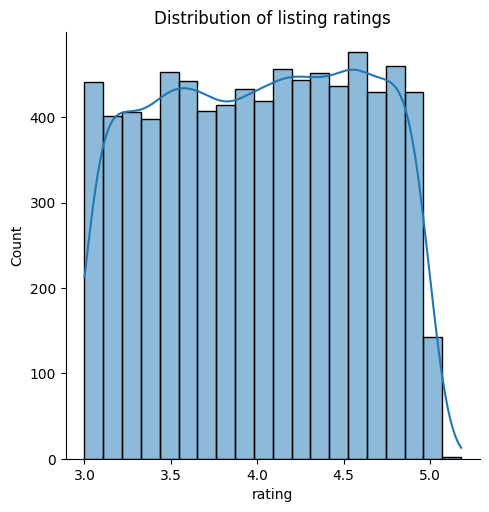

In [8]:
# Visualize the distribution of the rating column
sns.displot(airbnb['rating'], bins=20, kde=True)
plt.title('Distribution of listing ratings')
plt.show()

In [9]:
# Find number of unique values in room_type column
airbnb['room_type'].value_counts()

room_type
Entire home/apt         5120
Private room            4487
Shared room              155
Private                   89
   Shared room            71
home                      66
PRIVATE ROOM              31
Name: count, dtype: int64

- **Problem 8**: There are trailing spaces and capitalization issues with `room_type`, we need to fix this problem.

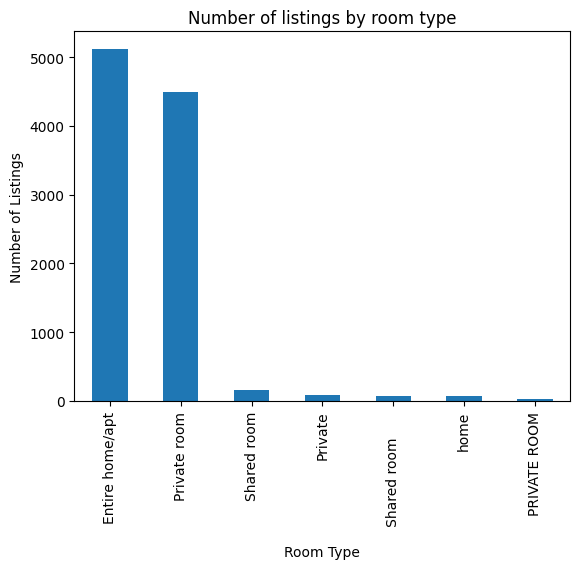

In [10]:
# How many values of different room_types do we have?
airbnb['room_type'].value_counts().plot(kind='bar')
plt.title('Number of listings by room type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.show()

## **Our to do list:**

_Data type problems:_

- **Task 1**: Split `coordinates` into 2 columns and convert them to `float`
- **Task 2**: Remove `$` from `price` and convert it to `float`
- **Task 3**: Convert `listing_added` and `last_review` to `datetime`

<br>

_Text/categorical data problems:_

- **Task 4**: We need to collapse `room_type` into correct categories
- **Task 5**: Divide `neighbourhood_full` into 2 columns and making sure they are clean

<br>

_Data range problems:_

- **Task 6**: Make sure we set the correct maximum for `rating` column out of range values

<br>

_Dealing with missing data:_

- **Task 7**: Understand the type of missingness, and deal with the missing data in most of the remaining columns.

<br>

_Is that all though?_

- We need to investigate if we duplicates in our data
- We need to make sure that data makes sense by applying some sanity checks on our DataFrame

## **Q&A**

## **Cleaning data**

### Data type problems

In [11]:
# Reminder of the DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


##### **Task 1:** Replace `coordinates` with `latitude` and `longitude` columns

To perform this task, we will use the following methods:

- `.str.replace("","")` replaces one string in each row of a column with another
- `.str.split("")` takes in a string and lets you split a column into two based on that string
- `.astype()` lets you convert a column from one type to another

In [12]:
# Remove "(" and ")" from coordinates
airbnb['coordinates'] = airbnb['coordinates'].str.replace('(', '').str.replace(')', '')
# Print the header of the column
airbnb['coordinates'].head()

0    40.63222, -73.93398
1    40.78761, -73.96862
2     40.7007, -73.99517
3    40.79169, -73.97498
4    40.71884, -73.98354
Name: coordinates, dtype: object

In [13]:
# Split column into two
airbnb[['latitude', 'longitude']] = airbnb['coordinates'].str.split(',', expand=True)
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","40.63222, -73.93398",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","40.78761, -73.96862",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","40.7007, -73.99517",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15,40.7007,-73.99517
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","40.79169, -73.97498",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","40.71884, -73.98354",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354


In [14]:
# Assign correct columns to latitude and longitude columns in airbnb
airbnb['latitude'] = airbnb['latitude'].astype('float')
airbnb['longitude'] = airbnb['longitude'].astype('float')
# Print the header and confirm new column creation
airbnb[['latitude', 'longitude']].head()


,latitude,longitude
0,40.63222,-73.93398
1,40.78761,-73.96862
2,40.70070,-73.99517
3,40.79169,-73.97498
4,40.71884,-73.98354


In [15]:
# Print out dtypes again
airbnb.dtypes


listing_id              int64
name                   object
host_id                 int64
host_name              object
neighbourhood_full     object
coordinates            object
room_type              object
price                  object
number_of_reviews       int64
last_review            object
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added          object
latitude              float64
longitude             float64
dtype: object

In [16]:
# Convert latitude and longitude to float
airbnb['longitude'] = airbnb['longitude'].astype('float')
airbnb['latitude'] = airbnb['latitude'].astype('float')
# Print dtypes again
airbnb.dtypes

listing_id              int64
name                   object
host_id                 int64
host_name              object
neighbourhood_full     object
coordinates            object
room_type              object
price                  object
number_of_reviews       int64
last_review            object
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added          object
latitude              float64
longitude             float64
dtype: object

In [17]:
# Drop coordinates column
airbnb = airbnb.drop(columns=['coordinates'])

##### **Task 2:** Remove `$` from `price` and convert it to `float`

To perform this task, we will be using the following methods:

- `.str.strip()` which removes a specified string from each row in a column
- `.astype()`

In [18]:
# Calculate mean of price without conversion
# airbnb['price'].mean()

In [19]:
# Remove $ from price before conversion to float
airbnb['price'] = airbnb['price'].str.strip('$')
# Print header to make sure change was done
airbnb['price'].head()

0     45
1    135
2    150
3     86
4    160
Name: price, dtype: object

In [20]:
# Convert price to float
airbnb['price'] = airbnb['price'].astype('float')
# Calculate mean of price after conversion
airbnb['price'].mean()

np.float64(150.90512217564665)

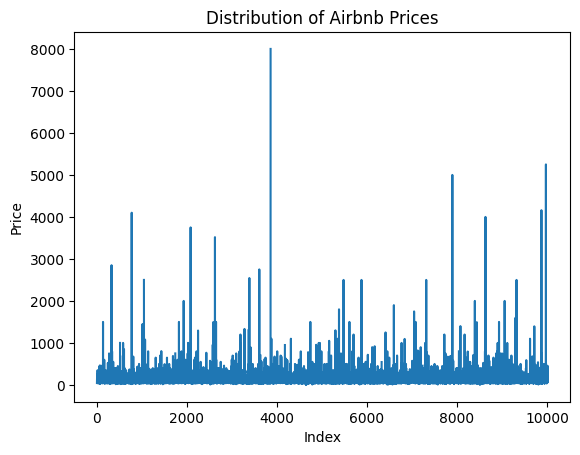

In [21]:
# Visualize distribution of prices
airbnb['price'].plot(kind='line')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Distribution of Airbnb Prices')
plt.show()



##### **Task 3:** Convert `listing_added` and `last_review` columns to `datetime`

To perform this task, we will use the following functions:

- `pd.to_datetime(format = "")`
  - `format` takes in the desired date format `"%Y-%m-%d"`

In [22]:
# Print header of two columns
airbnb[['listing_added', 'last_review']].head(n=2)

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30


In [23]:
# Convert both columns to datetime
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'], format='%Y-%m-%d')
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'], format='%Y-%m-%d')


In [24]:
# Print header and datatypes of both columns again

airbnb[['listing_added', 'last_review']].head()
airbnb[['listing_added', 'last_review']].dtypes

listing_added    datetime64[ns]
last_review      datetime64[ns]
dtype: object

### Text and categorical data problems

##### **Task 4:** We need to collapse `room_type` into correct categories

To perform this task, we will be using the following methods:

- `.str.lower()` to lowercase all rows in a string column
- `.str.strip()` to remove all white spaces of each row in a string column
- `.replace()` to replace values in a column with another

In [25]:
# Print unique values of `room_type`
airbnb['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Private', 'Shared room',
       'PRIVATE ROOM', 'home', '   Shared room      '], dtype=object)

In [26]:
# Deal with capitalized values
airbnb['room_type'] = airbnb['room_type'].str.lower()
airbnb['room_type'].unique()


array(['private room', 'entire home/apt', 'private', 'shared room',
       'home', '   shared room      '], dtype=object)

In [27]:
# Deal with trailing spaces
airbnb['room_type'] = airbnb['room_type'].str.strip()
airbnb['room_type'].unique()


array(['private room', 'entire home/apt', 'private', 'shared room',
       'home'], dtype=object)

In [28]:
# Replace values to 'Shared room', 'Entire place', 'Private room' and 'Hotel room' (if applicable).
airbnb['room_type'] = airbnb['room_type'].str.lower().replace({
    'private room': 'Private room',
    'home': 'Entire place',
    'shared room': 'Shared room',
    'hotel room': 'Hotel room',
    'entire home/apt': 'Entire place',
    'private': 'Private room',
})


# Replace values and collapse data
airbnb['room_type'].unique()

array(['Private room', 'Entire place', 'Shared room'], dtype=object)

##### **Task 5:** Divide `neighbourhood_full` into 2 columns and making sure they are clean

In [29]:
# Print header of column
airbnb['neighbourhood_full'].head()

0           Brooklyn, Flatlands
1    Manhattan, Upper West Side
2    Brooklyn, Brooklyn Heights
3    Manhattan, Upper West Side
4    Manhattan, Lower East Side
Name: neighbourhood_full, dtype: object

In [30]:
# Split neighbourhood_full
neighbourhood_split = airbnb['neighbourhood_full'].str.split(', ', expand=True)
neighbourhood_split.head()


,0,1
0,Brooklyn,Flatlands
1,Manhattan,Upper West Side
2,Brooklyn,Brooklyn Heights
3,Manhattan,Upper West Side
4,Manhattan,Lower East Side


In [31]:
# Create borough and neighbourhood columns
airbnb['borough'] = neighbourhood_split[1]
airbnb['neighbourhood'] = neighbourhood_split[0]

# Print header of columns
airbnb[['borough', 'neighbourhood']].head()


,borough,neighbourhood
0,Flatlands,Brooklyn
1,Upper West Side,Manhattan
2,Brooklyn Heights,Brooklyn
3,Upper West Side,Manhattan
4,Lower East Side,Manhattan


In [32]:
# Drop neighbourhood_full column
airbnb = airbnb.drop(columns=['neighbourhood_full'])

In [33]:
# Print out unique values of borough and neighbourhood
airbnb[['borough', 'neighbourhood']].nunique()

borough          198
neighbourhood      5
dtype: int64

In [34]:
# Strip white space from neighbourhood column
airbnb['neighbourhood'] = airbnb['neighbourhood'].str.strip()
# Print unique values again
airbnb['neighbourhood'].unique()


array(['Brooklyn', 'Manhattan', 'Queens', 'Bronx', 'Staten Island'],
      dtype=object)

##### **Task 6:** Make sure we set the correct maximum for `rating` column out of range values

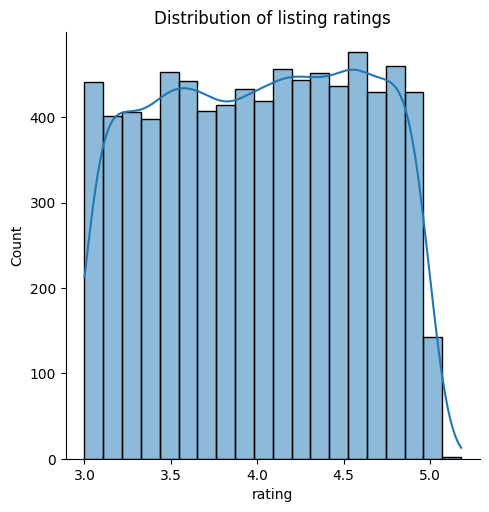

In [35]:
# Visualize the rating column again
sns.displot(airbnb['rating'], bins=20, kde=True)
plt.title('Distribution of listing ratings')
plt.show()

In [36]:
# Isolate rows of rating > 5.0
outliers = airbnb[airbnb['rating'] > 5.0]
row_count = outliers.shape[0]
print(f'Number of rows with rating > 5.0: {row_count}')

Number of rows with rating > 5.0: 3


In [37]:
# Drop these rows and make sure we have effected changes
airbnb = airbnb[airbnb['rating'] <= 5.0].copy()

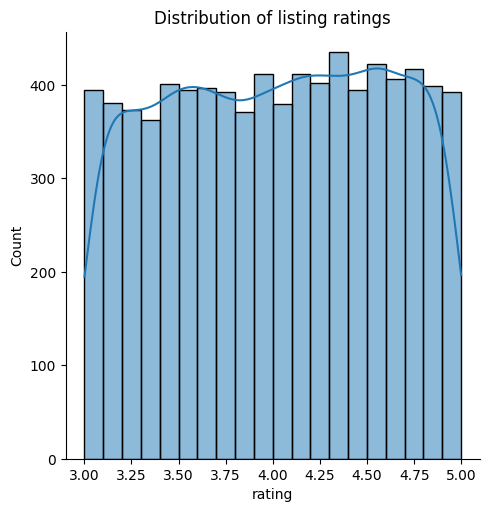

In [38]:
# Visualize the rating column again
sns.displot(airbnb['rating'], bins=20, kde=True)
plt.title('Distribution of listing ratings')
plt.show()

In [39]:
# Get the maximum
max = airbnb['rating'].max()
max

np.float64(4.999561104773598)

## **Q&A**

### Dealing with missing data

**Treating the** `rating`, `number_of_stays`, `5_stars`, `reviews_per_month` **columns**

In [40]:
# Understand DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month
airbnb[airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
count,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
min,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
max,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Looking at the missing data in the DataFrame - we can see that `number_of_reviews` across all missing rows is 0. We can infer that these listings have never been visited - hence could be inferred they're inactive/have never been visited.

We can impute them as following:

- Set `NaN` for `reviews_per_month`, `number_of_stays`, `5_stars` to 0.
- Since a `rating` did not happen, let's keep the column as is - but create a new column named `rated` that takes in `1` if yes, `0` if no.
- We will also leave `last_review` as is.

**Hint:** You can use a dictionary like `{'reviews_per_month': 0, 'number_of_stays': 0, '5_stars': 0}` with the `fillna` function to fill missing values in specific columns.


In [41]:
# Impute missing data
for i in ['rating', 'number_of_reviews', 'reviews_per_month']:
    airbnb[i] = airbnb[i].fillna(0)

# Create is_rated column
airbnb['is_rated'] = airbnb['rating'].notna().astype(int)


**Treating the** `price` **column**

In [42]:
# Investigate DataFrame with missing values in price
airbnb[airbnb['price'].isna()]

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
172,7116071,30 Minutes to Manhattan / Sleeps 7,36903907,Moe,Entire place,NaN,207,2019-07-02,4.26,287,3.990992,248.4,0.685576,2018-12-27,40.61112,-74.00028,Bensonhurst,Brooklyn,1
190,13395955,Adorable Prospect Heights 1 Bedroom,34468399,Nancy,Entire place,NaN,3,2018-07-21,0.08,0,3.449585,3.6,0.602585,2018-01-15,40.67649,-73.96697,Prospect Heights,Brooklyn,1
240,27903031,Prewar Gem in Middle of Everything!,7580102,(Email hidden by Airbnb),Private room,NaN,3,2018-11-17,0.31,0,3.914751,3.6,0.691139,2018-05-14,40.76399,-73.98077,Midtown,Manhattan,1
280,1700471,CHARM Rm HAMILTON HEIGHTS Harlem,8289663,Shane,Private room,NaN,101,2019-06-10,1.44,340,4.747851,121.2,0.913284,2018-12-05,40.81976,-73.94029,Harlem,Manhattan,1
333,30235482,*Groovy Budget room for the traveler!,226339724,David And Annette,Private room,NaN,5,2019-07-05,1.36,362,4.063096,6.0,0.660673,2018-12-30,40.68052,-73.91216,Bedford-Stuyvesant,Brooklyn,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9909,1420559,Great 1BR apartment in a convenient location,3349838,Tom,Entire place,NaN,4,2016-07-05,0.06,41,3.030241,4.8,0.654444,2015-12-31,40.74449,-73.95201,Long Island City,Queens,1
9961,6601120,Entire place in Williamsburg. Rustic Den.,34534668,Gohe,Entire place,NaN,5,2018-04-29,0.27,0,3.014789,6.0,0.616635,2017-10-24,40.71297,-73.96409,Williamsburg,Brooklyn,1
9972,18961150,Room with a view,5139965,Jamie,Entire place,NaN,3,2017-06-26,0.12,0,3.659673,3.6,0.785499,2016-12-21,40.75125,-73.93807,Long Island City,Queens,1
10009,1474752,Dope Williamsburg Apartment,2259113,Ange,Private room,NaN,23,2019-05-06,0.32,159,3.962641,27.6,0.734784,2018-10-31,40.71215,-73.95637,Williamsburg,Brooklyn,1


In [43]:
# Investigate DataFrame with missing values in price
airbnb['price'].isna().sum()

np.int64(191)

From a common sense perspective, the most predictive factor for a room's price is the `room_type` column, so let's visualize how price varies by room type with `sns.boxplot()` which displays the following information:


<p align="center">
<img src="boxplot.png" alt = "DataCamp icon" width="80%">
</p>




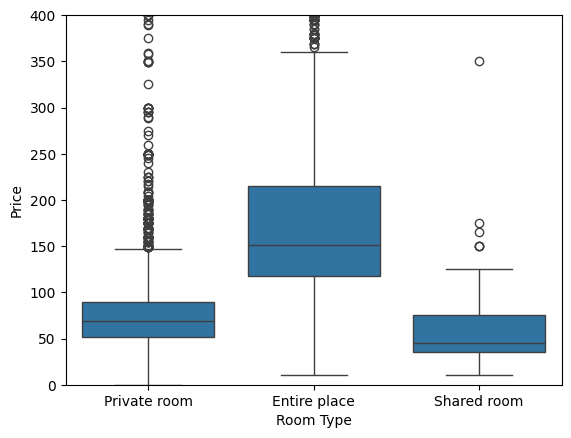

In [44]:
# Visualize relationship between price and room_type
sns.boxplot(x = 'room_type', y = 'price', data = airbnb)
plt.ylim(0, 400)
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()


In [45]:
# Get median price per room_type
median_price = airbnb.groupby('room_type')['price'].median()
median_price

room_type
Entire place    151.0
Private room     69.0
Shared room      45.0
Name: price, dtype: float64

In [46]:
# Impute price based on conditions
airbnb['price'] = airbnb.groupby('room_type')['price'].transform(lambda x: x.fillna(x.median()))

In [47]:
# Confirm price has been imputed
airbnb['price'].isna().sum()

np.int64(0)

### What's still to be done?

Albeit we've done a significant amount of data cleaning tasks, there are still a couple of problems we have yet to diagnose. When cleaning data, we need to consider:

- Values that do not make any sense *(for example: are there values of `last_review` that older than `listing_added`? Are there listings in the future?*)
- Presence of duplicates values - and how to deal with them?

##### **Task 8:** Do we have consistent date data?

In [51]:
# Doing some sanity checks on date data
print(airbnb['listing_added'].max())
print(airbnb['last_review'].max())

2020-10-23 00:00:00
2019-07-08 00:00:00


In [52]:
# Are there reviews in the future?
future = airbnb[airbnb['last_review'] > pd.Timestamp('now')]
future.shape[0]

0

In [53]:
# Are there listings in the future?
future_listings = airbnb[airbnb['listing_added'] > pd.Timestamp('now')]
future_listings.shape[0]

0

In [54]:
# Drop these rows since they are only 4 rows


In [55]:
# Are there any listings with listing_added > last_review

listing_false = airbnb[airbnb['listing_added'] > airbnb['last_review']]
listing_false.shape[0]

6

In [56]:
# Drop these rows since they are only 2 rows
airbnb = airbnb[airbnb['listing_added'] <= airbnb['last_review']].copy()

##### **Task 9:** Let's deal with duplicate data


There are two notable types of duplicate data:

- Identical duplicate data across all columns
- Identical duplicate data cross most or some columns

To diagnose, and deal with duplicate data, we will be using the following methods and functions:

- `.duplicated(subset = , keep = )`
  - `subset` lets us pick one or more columns with duplicate values.
  - `keep` returns lets us return all instances of duplicate values.
- `.drop_duplicates(subset = , keep = )`
  

In [57]:
# Print the header of the DataFrame again
airbnb.head()

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398,Flatlands,Brooklyn,1
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire place,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862,Upper West Side,Manhattan,1
3,6425850,"Spacious, charming studio",32715865,Yelena,Entire place,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498,Upper West Side,Manhattan,1
5,271954,Beautiful brownstone apartment,1423798,Aj,Entire place,150.0,203,2019-06-20,2.22,300,4.478396,243.6,0.743500,2018-12-15,40.73388,-73.99452,Greenwich Village,Manhattan,1
7,14218742,Luxury/3bedroom/3bthrm/Privateprkng/beach/rstrnts,78824908,Ilona,Entire place,224.0,2,2018-06-22,0.08,353,4.091228,2.4,0.690393,2017-12-17,40.58531,-73.93811,Sheepshead Bay,Brooklyn,1


In [58]:
# Find duplicates
airbnb.duplicated().sum()


np.int64(12)

In [ ]:
# Show all duplicates
duplicates = airbnb.duplicated()
duplicates

In [59]:
# Remove identical duplicates
airbnb.drop_duplicates(inplace=True)

In [60]:
# Find non-identical duplicates
airbnb.duplicated(subset=['name', 'host_name', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price']).sum()

np.int64(1)

To treat identical duplicates across some columns, we will chain the `.groupby()` and `.agg()` methods where we group by the column used to find duplicates (`listing_id`) and aggregate across statistical measures for `price`, `rating` and `list_added`. The `.agg()` method takes in a dictionary with each column's aggregation method - we will use the following aggregations:

- `mean` for `price` and `rating` columns
- `max` for `listing_added` column
- `first` for all remaining column

*A note on dictionary comprehensions:*

Dictionaries are useful data structures in Python with the following format
`my_dictionary = {key: value}` where a `key` is mapped to a `value` and whose `value` can be returned with `my_dictionary[key]` - dictionary comprehensions allow us to programmatically create dicitonaries using the structure:

```
{x: x*2 for x in [1,2,3,4,5]}
{1:2, 2:4, 3:6, 4:8, 5:10}
```

In [61]:
# Get column names from airbnb
columns = airbnb.columns
columns


Index(['listing_id', 'name', 'host_id', 'host_name', 'room_type', 'price',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'availability_365', 'rating', 'number_of_stays', '5_stars',
       'listing_added', 'latitude', 'longitude', 'borough', 'neighbourhood',
       'is_rated'],
      dtype='object')

In [62]:
# Create dictionary comprehension with 'first' as value for all columns not being aggregated
dictionary = {col: 'first' for col in airbnb.columns if col not in ['reviews_per_month', 'number_of_reviews', 'rating']}
dictionary.update({'reviews_per_month': 'mean', 'number_of_reviews': 'sum', 'rating': 'mean'})
dictionary





{'listing_id': 'first',
 'name': 'first',
 'host_id': 'first',
 'host_name': 'first',
 'room_type': 'first',
 'price': 'first',
 'last_review': 'first',
 'availability_365': 'first',
 'number_of_stays': 'first',
 '5_stars': 'first',
 'listing_added': 'first',
 'latitude': 'first',
 'longitude': 'first',
 'borough': 'first',
 'neighbourhood': 'first',
 'is_rated': 'first',
 'reviews_per_month': 'mean',
 'number_of_reviews': 'sum',
 'rating': 'mean'}

In [63]:
# Remove non-identical duplicates
airbnb = airbnb.groupby(['name', 'host_name', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price'], as_index=False).agg(dictionary)

In [64]:
# Make sure no duplication happened
airbnb.duplicated(subset=['name', 'host_name', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price']).sum()

np.int64(0)

In [65]:
# Print header of DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,room_type,price,last_review,availability_365,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated,reviews_per_month,number_of_reviews,rating
0,4444204,2-3 bedroom UWS garden triplex,5162192,Amy,Entire place,300.0,2015-10-06,310,4.8,0.644580,2015-04-02,40.79795,-73.96175,Upper West Side,Manhattan,1,0.07,4,4.205238
1,1404510,A charming Space in Brooklyn,7557833,Christine,Private room,95.0,2019-01-25,47,52.8,0.776738,2018-07-22,40.69180,-73.94673,Bedford-Stuyvesant,Brooklyn,1,0.64,44,4.042730
2,2880336,quaint apartment with city views,14720647,Christian,Entire place,95.0,2015-12-25,0,30.0,0.720210,2015-06-21,40.71046,-73.91786,Ridgewood,Queens,1,0.40,25,4.079936
3,16852728,!!! Outpost Coliving . Shared twin room,2092314,Valentin,Shared room,26.0,2018-04-30,365,2.4,0.768555,2017-10-25,40.65024,-73.95051,East Flatbush,Brooklyn,1,0.09,2,3.485213
4,6376345,!!BEAUTIFUL APARTMENT WITH GARDEN!!,33232851,Luis,Entire place,40.0,2016-02-01,0,2.4,0.712048,2015-07-29,40.87494,-73.91057,Marble Hill,Manhattan,1,0.05,2,4.795113


## **Q&A**

### Take home question

Try to answer the following questions about the dataset:

- What is the average price of listings by borough? Visualize your results with a bar plot!
- What is the average availability in days of listings by borough? Visualize your results with a bar plot!
- What is the median price per room type in each borough? Visualize your results with a bar plot!
- Visualize the number of listings over time.

**Functions that should/could be used:**
- `.groupby()` and `.agg(})`
- `sns.barplot(x = , y = , hue = , data = )`
- `sns.lineplot(x = , y = , data = )`
- `.dt.strftime()` for extracting specific dates from a `datetime` column
